In [48]:
from flonacomldft.utils.io_utils import load_pickle_file
import matplotlib.pyplot as plt
import numpy as np
import torch

In [49]:
init_flow = load_pickle_file("database/berendsen/models/is0_flow_dic_training_20230520201411.pkl")

Text(0, 0.5, 'Loss')

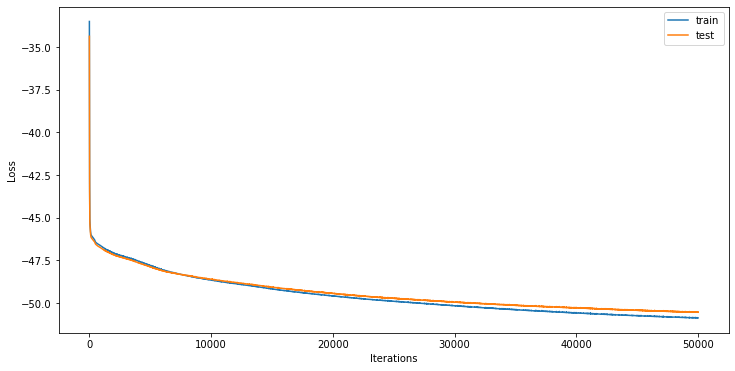

In [50]:
losses = init_flow["losses"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(losses[0], label="train")
ax.plot(losses[1], label="test")
ax.legend()
ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')

In [51]:
adapt = load_pickle_file("adaptative_sampling_2406684.pkl", path="/mnt/home/amolina/ceph/simulations/adaptive_samp_1/")

In [52]:
from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.plots import set_plot_iteration

In [53]:
n_chains = adapt['args']['n_chains']

In [27]:
accs = torch.stack(adapt['accs'])
accs_flatten = accs.reshape(-1, n_chains)

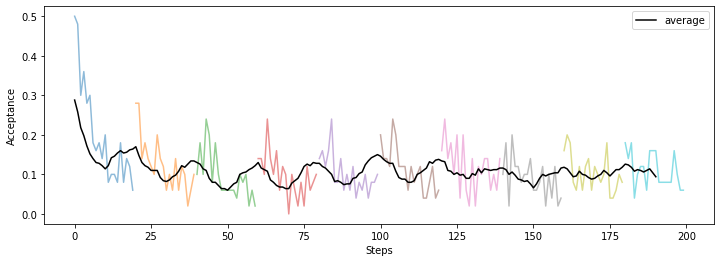

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(12,6) )
i=0
for acc in accs:
    set_plot_iteration(acc.mean(dim=1), avg=False, window_size=10, axis=1, ax=ax, init=i)
    if i > 0:
        i += acc.shape[0]
    else:
        i += acc.shape[0]

window_size = 10
axis = 1

x_avg = np.arange(len(avg_windows(accs_flatten.mean(dim=1), window_size, axis)))
y_avg = avg_windows(accs_flatten.mean(dim=1), window_size, axis)
ax.plot(x_avg, y_avg, color="k", label='average')

ax.set_xlabel('Steps')
ax.set_ylabel('Acceptance')
ax.legend()

In [32]:
len(dict_flows_training[0])

1

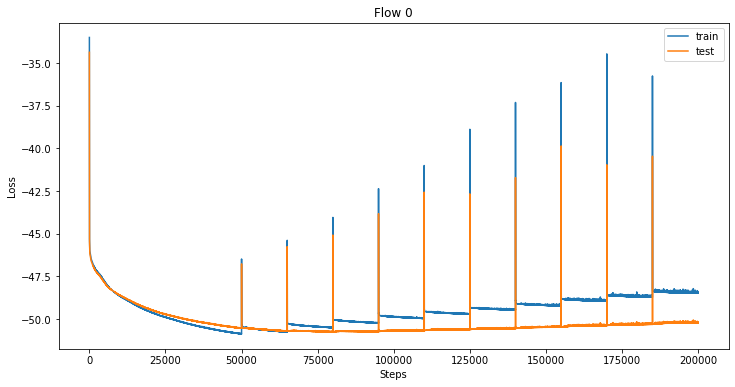

In [54]:
dict_flows_training = adapt['dict_flows_training']

for j in range(1):

    losses_train = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])
    losses_test = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][1]) for i in range(len(dict_flows_training))])

    y_lines = np.cumsum([len(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])

    fig, ax = plt.subplots(1, 1, figsize=(12,6) )
    set_plot_iteration(losses_train, avg=False, window_size=10, axis=0, alpha=1, ax=ax, label='train')
    set_plot_iteration(losses_test, avg=False, window_size=10, axis=0,alpha=1, ax=ax, label='test')

    ax.vlines(y_lines, ymin=torch.log(losses_train.min()), ymax=torch.log(losses_train.max()), color='k', alpha=0.2, linestyle='--')

    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    ax.set_label(['train', 'test'])
    ax.legend()

    ax.set_title('Flow {}'.format(j))  